In [1]:
import numpy as np

# Define two vectors
a = np.array([3, 4])
b = np.array([2, 1])

# 1. Dot product
dot_product = np.dot(a, b)

# 2. Magnitudes (norms)
magnitude_a = np.linalg.norm(a)
magnitude_b = np.linalg.norm(b)

# 3. Cosine of angle between vectors
cos_theta = dot_product / (magnitude_a * magnitude_b)

# 4. Angle in degrees
angle_degrees = np.degrees(np.arccos(cos_theta))

# 5. Projection of a onto b
unit_b = b / magnitude_b
projection_a_on_b = np.dot(a, unit_b) * unit_b

(dot_product, magnitude_a, magnitude_b, cos_theta, angle_degrees, projection_a_on_b)


(np.int64(10),
 np.float64(5.0),
 np.float64(2.23606797749979),
 np.float64(0.8944271909999159),
 np.float64(26.565051177077994),
 array([4., 2.]))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# 1. Create inputs x (shape: [N, 1])
np.random.seed(42)
N = 100                        # number of data points
x = np.linspace(-5, 5, N).reshape(-1, 1)

In [11]:
# 2. True function: y = 2x + 3
true_w = 2.0
true_b = 3.0
y_true = true_w * x + true_b

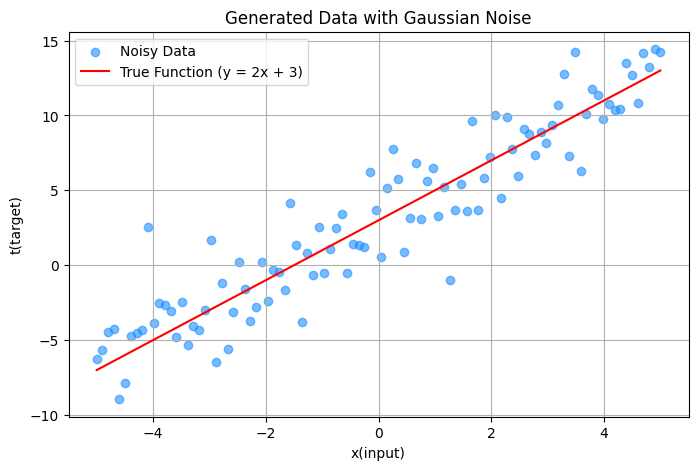

In [17]:
# 3. Add Gaussian noise to outputs
noise = np.random.normal(0, 2.0, size=y_true.shape)  # mean=0, std=2
y_noisy = y_true + noise

# 4. Visualize
plt.figure(figsize=(8, 5))
plt.scatter(x, y_noisy, label='Noisy Data', color='dodgerblue', alpha=0.6)
plt.plot(x, y_true, label='True Function (y = 2x + 3)', color='red')
plt.xlabel('x(input)')
plt.ylabel('t(target)')
plt.title('Generated Data with Gaussian Noise')
plt.legend()
plt.grid(True)
plt.show()

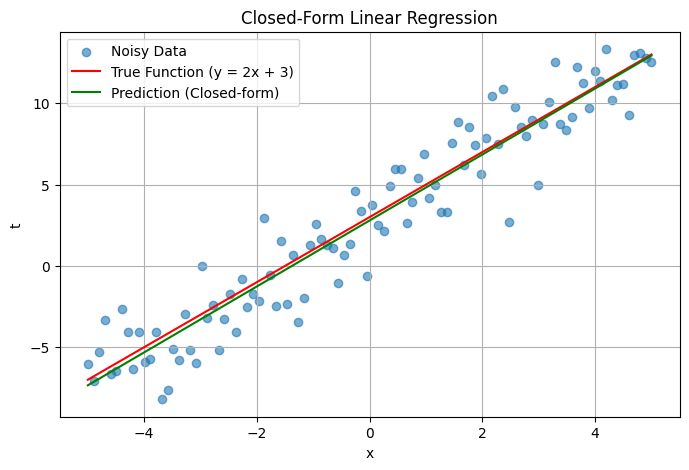

Learned weight (w1): 2.0275865346733144
Learned bias   (w0): 2.792306965211812


In [19]:

import numpy as np
import matplotlib.pyplot as plt

# === STEP 1: Generate data ===
np.random.seed(42)
N = 100
x = np.linspace(-5, 5, N).reshape(-1, 1)
true_w = 2.0
true_b = 3.0
y_true = true_w * x + true_b
noise = np.random.normal(0, 2.0, size=y_true.shape)
y_noisy = y_true + noise

# === STEP 2: Add bias term (x0 = 1) to input ===
X = np.hstack([np.ones_like(x), x])   # Shape: (N, 2), [1, x] for each sample

# === STEP 3: Apply closed-form solution ===
# Formula: w = (X^T X)^(-1) X^T y
w_closed = np.linalg.inv(X.T @ X) @ X.T @ y_noisy

# === STEP 4: Predict ===
y_pred = X @ w_closed

# === STEP 5: Visualize ===
plt.figure(figsize=(8, 5))
plt.scatter(x, y_noisy, label='Noisy Data', alpha=0.6)
plt.plot(x, y_true, label='True Function (y = 2x + 3)', color='red')
plt.plot(x, y_pred, label='Prediction (Closed-form)', color='green')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Closed-Form Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

# === STEP 6: Print learned parameters ===
print("Learned weight (w1):", w_closed[1][0])
print("Learned bias   (w0):", w_closed[0][0])


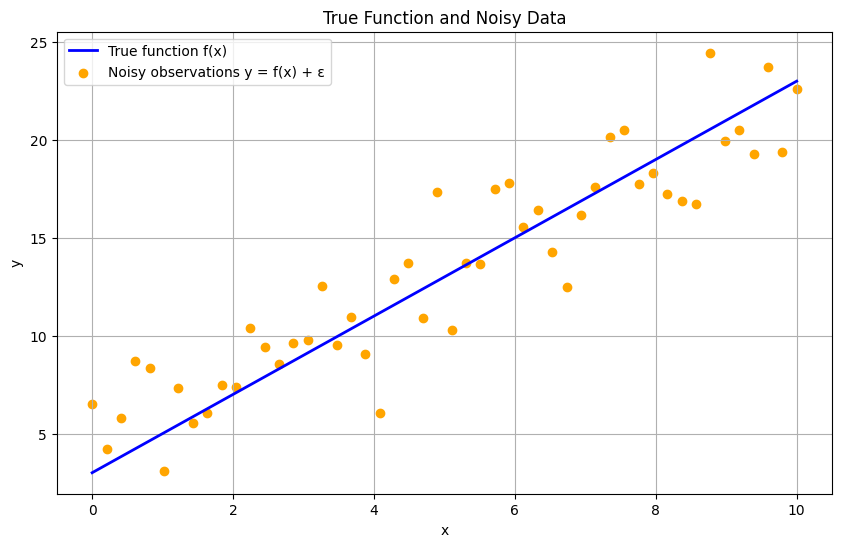

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Define true function (no noise)
def f(x):
    return 2 * x + 3  # simple linear function

# 2. Generate input data
np.random.seed(0)
x = np.linspace(0, 10, 50)
true_y = f(x)

# 3. Add Gaussian noise
sigma = 2.0
noise = np.random.normal(0, sigma, size=x.shape)
y_observed = true_y + noise

# 4. Plot true function and noisy observations
plt.figure(figsize=(10, 6))
plt.plot(x, true_y, label='True function f(x)', color='blue', linewidth=2)
plt.scatter(x, y_observed, label='Noisy observations y = f(x) + ε', color='orange')
plt.title('True Function and Noisy Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


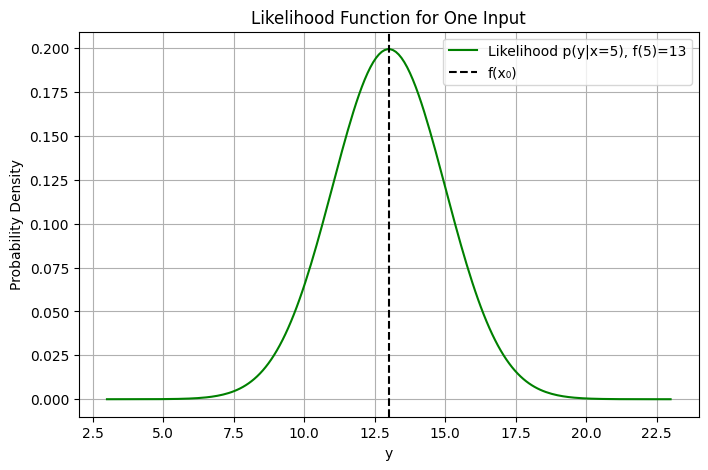

In [2]:
# Choose one x₀
x0 = 5
fx0 = f(x0)

# y values around fx0 for the PDF
y_vals = np.linspace(fx0 - 10, fx0 + 10, 200)
likelihood = norm.pdf(y_vals, loc=fx0, scale=sigma)

# Plot the likelihood
plt.figure(figsize=(8, 5))
plt.plot(y_vals, likelihood, label=f'Likelihood p(y|x=5), f(5)={fx0}', color='green')
plt.axvline(fx0, linestyle='--', color='black', label='f(x₀)')
plt.title('Likelihood Function for One Input')
plt.xlabel('y')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


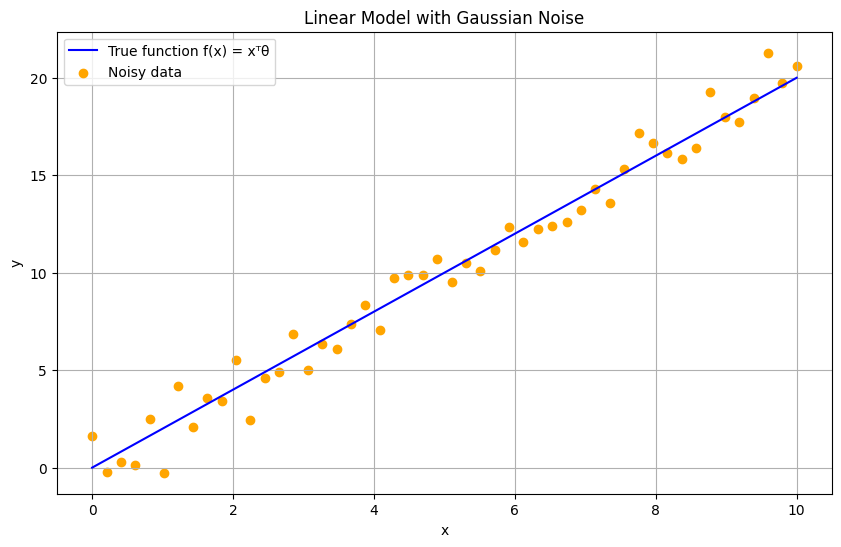

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Inputs and true parameters
np.random.seed(1)
x = np.linspace(0, 10, 50)
X = np.vstack([x]).T  # shape (50, 1)
theta_true = np.array([2.0])
sigma = 1.0

# Generate data: y = x^T * theta + noise
y_true = X @ theta_true
noise = np.random.normal(0, sigma, size=y_true.shape)
y_obs = y_true + noise

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_true, label='True function f(x) = xᵀθ', color='blue')
plt.scatter(x, y_obs, label='Noisy data', color='orange')
plt.title("Linear Model with Gaussian Noise")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


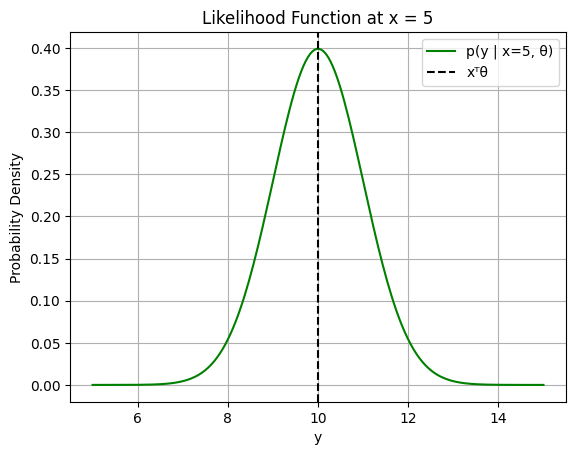

In [4]:
# Pick one x
x0 = 5
f_x0 = x0 * theta_true[0]

y_vals = np.linspace(f_x0 - 5, f_x0 + 5, 200)
likelihood = norm.pdf(y_vals, loc=f_x0, scale=sigma)

plt.plot(y_vals, likelihood, label=f'p(y | x={x0}, θ)', color='green')
plt.axvline(f_x0, linestyle='--', color='black', label='xᵀθ')
plt.title("Likelihood Function at x = 5")
plt.xlabel("y")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()
